In [11]:
import pandas as pd
import pylab as plt
import seaborn as sns
import numpy as np
pd.options.mode.chained_assignment = None  # default='warn'

sns.set(font_scale=1.2,style="whitegrid")
%matplotlib inline

#Import style guide to make plots
import sys
sys.path.append('../../../../tjn_tools/')

from style_guide import *
#Import some data_processing tools to convert names to ISO3 
from data_processing import *


#Avoid overlapping text|
from adjustText import adjust_text
from datetime import datetime


import statsmodels.formula.api as smf
from itertools import permutations, product
import pickle

pd.set_option('display.max_columns', 100)

In [12]:
path_files = "../data/raw/"
path_files_final = "../data/final/"
path_files_temp = "../data/processing/"

year_cbcr = 2017 #CBCR year to study

# now = datetime.now().year
last_year_mean = year_cbcr-6 #from now until 10 years ago

## Section 1
#Input
cbcr_file = f"{path_files}CBCR_TABLEI_02082021105119173.csv"

orbis_file = f"{path_files}orbis.xlsx"

#Output
etr_output = f"{path_files_final}{year_cbcr}_cbcr_etr_rates.xlsx"
cbcr_output = f"{path_files_final}{year_cbcr}_cbcr_cleaned_dividends.xlsx"


## Section 2
#Input
country_level = "../../../../Final data/20210810_country-level-data.csv"
country_year_level = "../../../../Final data/20210810_country-year-level-data.csv"
bilateral_level = "../../../../Final data/20210810_bilateral-year-level-data.csv"
grav_file = "../../../../Source data/022 CEPII/Gravity_V202102.dta"
link_file = "../../../../Source data/016 Papers/garcia-stausholm2020/combined_data_imputed copy.tsv"

#Output
df_pairs_output = f"{path_files_final}{year_cbcr}_df_pairs.tsv"
df_fin_output = f"{path_files_final}{year_cbcr}_df_fin.tsv"
d_groups2countries_output = f"{path_files_final}{year_cbcr}_d_groups2countries.dump"
iso3_to_wages_output = f"{path_files_final}{year_cbcr}_iso3_to_wages.dump"
iso3_to_cit_output = f"{path_files_final}{year_cbcr}_iso3_to_cit.dump"
iso3_to_gdp_output = f"{path_files_final}{year_cbcr}_iso3_to_gdp.dump"
info_expenditures_output = f"{path_files_final}{year_cbcr}_info_expenditures.csv"



In [13]:
#OFCs
ofcs = {'MLT', 'BRB', 'BMU', 'CUW', 'CYP', 'HKG', 'PRI', 'SGP', 'IRL', 'MUS', 'VGB', 'CYM', 
              'LUX', 'JEY', 'IMN', 'NLD', 'GIB', 'CHE', 'BHS', 'GGY', 'MAC', 'HUN', 'ARE'}
groups = {"ASIAT","EUROP","AMER","AFRIC",'OTE','OAM',"OAF","OAS"} 
#Other america and other europe usualyl contain many tax havens. When split only by continent, remove across all conutries


In [14]:
#CIT rates
cit_file = f"{path_files}corporate tax rates.csv" #tax rate
iso3_to_cit  = pd.read_csv(cit_file)
iso3_to_cit = iso3_to_cit.loc[iso3_to_cit["year"]==year_cbcr].groupby("country_iso3")["nctr_final"].mean()

iso3_to_cit["MLT"] *= 1/7 #(6/7th rule)
iso3_to_cit["GIB"] = 0 #only resident income
iso3_to_cit["MCO"] = 0
iso3_to_cit["AND"] = 0
iso3_to_cit["CAF"] = 0.3
iso3_to_cit["HTI"] = 0.3
iso3_to_cit["YEM"] = 0.2
iso3_to_cit["NCL"] = 0 #Only NCL income is taxable
iso3_to_cit["PRK"] = 0.325
iso3_to_cit["COD"] = 0.28
iso3_to_cit["TLS"] = 0.10
iso3_to_cit["ROU"] = iso3_to_cit["ROM"]
iso3_to_cit["USA"] = 0.27 # State tax included

pickle.dump(iso3_to_cit,open(iso3_to_cit_output,"wb+"))

In [15]:
for i in set(iso3_to_cit[np.isnan(iso3_to_cit)].index):
    print(i,iso3_to_name(i))

SOM Somalia
MTQ Martinique
TON Tonga
FSM Micronesia
HMD Heard Island and McDonald Islands
TMP Timor-Leste
COM Comoros
GUY Guyana
PYF French Polynesia
GUF French Guiana
KIR Kiribati
SJM Svalbard and Jan Mayen Islands
LBR Liberia
NIU Niue
PCN Pitcairn
STP Sao Tome and Principe
GLP Guadeloupe
SSD South Sudan
BLZ Belize
ERI Eritrea
SMR San Marino
TUV Tuvalu
IRN Iran
MHL Marshall Islands
NFK Norfolk Island
ESH Western Sahara
NRU Nauru
VGB British Virgin Islands
CXR Christmas Island
ATA Antarctica
REU Reunion
WLF Wallis and Futuna Islands
BVT Bouvet Island
SGS South Georgia and the South Sandwich Islands
GRL Greenland
CUB Cuba
IOT British Indian Ocean Territory
FRO Faroe Islands
MSR Montserrat
SHN Saint Helena
TKL Tokelau
VAT Vatican
ANT Netherlands Antilles
CCK Cocos Islands
MNP Northern Mariana Islands
VIR US Virgin Islands
FLK Falkland Islands
MYT Mayotte
COK Cook Islands


# 1. Clean CBCR data and calculate ETR
- Input file: CBCR (https://stats.oecd.org/Index.aspx?DataSetCode=CBCR_TABLEI)
- Orbis with number of expected companies
    - Columns needed:
        - Country ISO code
        - Operating revenue
        - Number of employees
        - GUO code
    - Search strategy:
        - Status: Active companies, Unknown situation
        - Operating revenue (Turnover), using estimates (m USD): min=850, Last available year, exclusion of companies with no recent financial data and Public authorities/States/Governments
        - Ultimate Owners: Global; Def. of the UO: min. path of 50.01%, known or unknown shareholder
        - Shareholders with foreign subsidiaries: located anywhere (excluding unknown countries) not ultimately owned but at least 51% owned; May have other shareholder in the foreign country; Def. of the UO: min. path of 50.01%, known or unknown shareholder
        - NACE Rev. 2, core code (4 digits): Different from 65


In [16]:
fin_needed = ['Unrelated Party Revenues','Profit (Loss) before Income Tax', 'Adjusted Profit (Loss) before Income Tax',
       'Income Tax Paid (on Cash Basis)','Income Tax Accrued - Current Year','Number of Employees',
       'Tangible Assets other than Cash and Cash Equivalents','Number of CbCRs','Number of CbCR Sub Groups','Number of Entities']

In [17]:
## Functions to calculate ETRs
def calculate_etr(df):
    d = df.loc[df["Income Tax Paid (on Cash Basis)"]>=0].groupby("JUR").sum()
    d["etr"] = d["Income Tax Paid (on Cash Basis)"]/d["Profit (Loss) before Income Tax"]
    return d["etr"]

def main_etrs(year,file,g="Sub-Groups with positive profits"):
    if isinstance(file,str):
        df = pd.read_csv(file,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
        df = df.loc[df["Grouping"]==g]
        df = df.loc[df["Variable"].isin(fin_needed)]
        df = df.loc[df["Year"]==year]
        df = pd.pivot_table(df,index=["COU","JUR","Partner Jurisdiction"],values="Value",columns="Variable").reset_index()
    else:
        df = file
    df = df.dropna(subset=["Income Tax Paid (on Cash Basis)"])

    df_for = df.loc[df["COU"] != df["JUR"]]
    df_dom = df.loc[df["COU"] == df["JUR"]]
    df_tot = df

    df_etr = pd.concat([calculate_etr(df_for),
                       calculate_etr(df_dom),
                       calculate_etr(df_tot)],
                      axis=1)
    df_etr.columns = ["ETR_foreign","ETR_domestic","ETR_total"]
    return df_etr
#     df_etr.to_excel(etr_output)

#     df_etr.head()

## 1.1 CBCR vs Orbis: Compare coverage

In [ ]:
#CBCR number of companies
total_cov = pd.read_csv(cbcr_file,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
total_cov = total_cov.loc[total_cov["Year"]==year_cbcr]
total_cov = total_cov.loc[total_cov["Grouping"]=="All Sub-Groups"]
total_cov = total_cov.loc[total_cov["Variable"]=="Number of CbCRs"]
total_cov = total_cov.loc[total_cov["JUR"]==total_cov["COU"]]
total_cov = total_cov.groupby(["COU"]).max()["Value"]

## Compare quality with Orbis (companies with >750M of turnover, including estimates, and keeping companies with foreign subsidiaries)
cs = pd.read_excel(orbis_file,na_values=["n.a."],keep_default_na=False)
cs = cs.dropna(subset=["GUO - BvD ID number"])
cs = cs.loc[(cs["Country ISO code"]==cs["GUO - BvD ID number"].str[:2])|(cs["GUO - BvD ID number"].str[:2]=="WW")]
cs["max_turnover"] = cs.groupby(["GUO - BvD ID number"])["Operating revenue (Turnover)\nth USD Last avail. yr"].transform(max)
cs = cs.loc[cs["Operating revenue (Turnover)\nth USD Last avail. yr"]==cs["max_turnover"]]
print(cs["GUO - BvD ID number"].value_counts().head()) #makek sure no repeated, in case of equal turnovers

cs = cs.drop_duplicates(subset=["GUO - BvD ID number"])
cs.loc[(cs["Country ISO code"]!=cs["GUO - BvD ID number"].str[:2])&(cs["GUO - BvD ID number"].str[:2]!="WW"),"Country ISO code"] = cs.loc[(cs["Country ISO code"]!=cs["GUO - BvD ID number"].str[:2])&(cs["GUO - BvD ID number"].str[:2]!="WW"),"GUO - BvD ID number"].str[:2]
print(cs["GUO - BvD ID number"].value_counts().head()) #makek sure no repeated, in case of equal turnovers

cs = cs.groupby("Country ISO code").agg({"GUO - BvD ID number": len,"Operating revenue (Turnover)\nth USD Last avail. yr":np.sum,"Number of employees\nLast avail. yr":np.sum}).reset_index()
cs.columns = ["country","Number companies expected","Turnover expected","Emp expected"]
cs["Turnover expected"] *= 1000
cs["country"] = cs["country"].map(get_iso3)
cs = cs.dropna(subset=["country"])

#This array is used in 99.cluster_photoshop
potential_countries = cs.loc[cs["Number companies expected"]>=3,"country"].values

cs = pd.concat([cs.set_index("country"),total_cov],axis=1)
cs["Coverage"] = np.log2(cs["Value"]/cs["Number companies expected"])


cs_plot = cs.dropna()
plt.figure(figsize=(8,6))
plt.plot(cs_plot["Number companies expected"],cs_plot["Coverage"],"o",color="gray")

texts = []
for c,x,y in zip(cs_plot.index,cs_plot["Number companies expected"],cs_plot["Coverage"]):
    texts.append(plt.text(x,y,iso3_to_name(c)))


plt.plot([4,1800],[0,0],alpha=0.5,color="gray")             
plt.xscale("log")

adjust_text(texts,cs_plot["Number companies expected"].values, cs_plot["Coverage"].values, 
            arrowprops=dict(arrowstyle='->', color='gray'))
bins = np.array([0.25,0.5,0.75,1,1.5,2,4])
coverage = np.log2(bins)
plt.yticks(coverage,np.array(100*bins,dtype=int))
plt.xlabel("Expected firms")
plt.ylabel("Coverage (%)")
sns.despine(bottom=False,left=True)


expected_companies = cs["Number companies expected"]
expected_companies = expected_companies.to_dict()
expected_companies["DNK"]

In [50]:
cs_plot["Ratio"] = cs_plot["Number companies expected"]/cs_plot["Value"]
x = cs_plot[["Number companies expected","Value","Ratio"]].sort_values(by="Ratio", ascending=False)
x.index = x.index.map(iso3_to_name)
x["Number companies expected"] = x["Number companies expected"].astype(int)
x["Value"] = x["Value"].astype(int)
x["Ratio"] = x["Ratio"].round(2)
x

,Number companies expected,Value,Ratio
China,538,264,2.04
Malaysia,41,34,1.21
Bermuda,49,48,1.02
South Korea,221,221,1.00
South Africa,50,51,0.98
Sweden,94,102,0.92
Japan,785,866,0.91
Switzerland,64,71,0.90
United States,1334,1487,0.90
Denmark,54,64,0.84


In [25]:
potential_countries.values

array(['ARE', 'ARG', 'AUT', 'AUS', 'BEL', 'BHR', 'BMU', 'BRA', 'CAN',
       'CHE', 'CHL', 'CHN', 'COL', 'CYP', 'CZE', 'DEU', 'DNK', 'EGY',
       'ESP', 'FIN', 'FRA', 'GBR', 'GRC', 'HKG', 'HUN', 'IDN', 'IRL',
       'ISR', 'IND', 'IRN', 'ITA', 'JPN', 'KOR', 'KWT', 'CYM', 'KAZ',
       'LUX', 'MAR', 'MEX', 'MYS', 'NGA', 'NLD', 'NOR', 'NZL', 'PAN',
       'PER', 'PHL', 'POL', 'PRT', 'QAT', 'RUS', 'SAU', 'SWE', 'SGP',
       'SVN', 'THA', 'TUR', 'TWN', 'USA', 'VGB', 'VNM', 'ZAF'],
      dtype=object)

In [8]:
df = pd.read_csv(cbcr_file,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
# df = df.loc[df["Grouping"]=="Sub-Groups with positive profits"]
df = df.loc[df["Grouping"]=="All Sub-Groups"]
df = df.loc[df["Year"]==year_cbcr]
df = df.loc[df["Variable"].isin(fin_needed)]
df = pd.pivot_table(df,index=["COU","JUR","Partner Jurisdiction"],values="Value",columns="Variable").reset_index()
if "Adjusted Profit (Loss) before Income Tax" in list(df.columns):
    df.dropna(subset=["Adjusted Profit (Loss) before Income Tax"])[["JUR","Profit (Loss) before Income Tax", "Adjusted Profit (Loss) before Income Tax"]].set_index("JUR")/1E9

In [43]:
df = pd.read_csv(cbcr_file)
df = df.loc[df["Year"]==2017]
df1 = df.loc[df["Grouping"]=="Sub-Groups with positive profits"]
a = df1[["COU","Partner Jurisdiction"]].drop_duplicates().reset_index(drop=True)["COU"].value_counts()

df1 = df.loc[df["Grouping"]=="All Sub-Groups"]
b = df1[["COU","Partner Jurisdiction"]].drop_duplicates().reset_index(drop=True)["COU"].value_counts()

pd.concat([b,a],axis=1).transpose().fillna(0).astype(int)

,JPN,IND,DEU,USA,ZAF,CHN,CHE,ESP,DNK,ITA,BMU,MEX,LUX,FRA,AUS,IDN,BRA,MYS,SGP,BEL,PER,ARG,CAN,LVA,CHL,GBR,SWE,ROU,SVN,IMN,GRC,AUT,NOR,POL,NLD,FIN,KOR,IRL
COU,200,164,161,147,139,125,122,120,115,110,101,97,92,90,82,43,43,36,29,21,20,19,16,14,10,7,7,7,7,7,6,6,6,5,2,2,2,2
COU,185,135,158,99,115,92,121,80,115,81,69,61,91,40,57,31,31,27,38,21,12,15,16,0,10,6,7,7,6,7,6,5,6,0,2,2,2,2


In [9]:
#Make sure the cleaning in 2016  (multiplying everything by 2 in china) was mostly okay
df = pd.read_csv(cbcr_file,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
df = df.loc[df["Grouping"]=="Sub-Groups with positive profits"]
# df = df.loc[df["Grouping"]=="All Sub-Groups"]
df = df.loc[df["Variable"].isin(fin_needed+['Number of CbCRs'])]
df = pd.pivot_table(df,index=["Year","COU","JUR","Partner Jurisdiction"],values="Value",columns="Variable").reset_index()
# df.dropna(subset=["Adjusted Profit (Loss) before Income Tax"])[["JUR","Profit (Loss) before Income Tax", "Adjusted Profit (Loss) before Income Tax"]].set_index("JUR")/1E9
df.loc[(df["JUR"]=="COD")]


Variable,Year,COU,JUR,Partner Jurisdiction,Adjusted Profit (Loss) before Income Tax,Income Tax Accrued - Current Year,Income Tax Paid (on Cash Basis),Number of CbCR Sub Groups,Number of CbCRs,Number of Employees,Number of Entities,Profit (Loss) before Income Tax,Tangible Assets other than Cash and Cash Equivalents,Unrelated Party Revenues
853,2016,ZAF,COD,Democratic Republic of the Congo,NaN,4.379733e+06,5.813607e+06,4.0,4.0,177.0,7.0,55954533.0,4.693023e+07,1.019855e+08
1289,2017,CHN,COD,Democratic Republic of the Congo,NaN,1.869742e+07,1.155755e+07,7.0,7.0,4057.0,19.0,68889224.0,6.037538e+08,1.684346e+08
2043,2017,JPN,COD,Democratic Republic of the Congo,NaN,1.052030e+06,5.057420e+05,1.0,1.0,234.0,2.0,3795278.0,2.943714e+07,6.015086e+07
2573,2017,ZAF,COD,Democratic Republic of the Congo,NaN,3.601608e+06,1.790003e+06,2.0,2.0,149.0,2.0,10299477.0,3.474348e+07,7.490633e+07


## 1.2 Read and clean CBCR
- Data limitations: https://www.oecd.org/tax/tax-policy/anonymised-and-aggregated-cbcr-statistics-disclaimer.pdf
- Report: https://www.oecd.org/tax/tax-policy/corporate-tax-statistics-database.htm


- Data on the United States --> Cleaned in the paper with Zucman
    - US domestic: 55%
    - US foreign: 7% (https://gabriel-zucman.eu/files/GBJZ2021.pdf)

- Other countries: correct using notes when possible:
    - Ireland: https://www.oecd.org/tax/tax-policy/ireland-cbcr-country-specific-analysis.pdf
        --> No issues found
    - Italy: https://www.oecd.org/tax/tax-policy/italy-cbcr-country-specific-analysis.pdf
        -->  The average value of the share of dividends is instead equal to 38.2%, thus implying that dividends are concentrated in few firms.  
    - Netherlands: https://www.oecd.org/tax/tax-policy/united-kingdom-cbcr-country-specific-analysis.pdf
        --> 5794 out of 36802 = 15.74%
    - United Kingdom: https://www.oecd.org/tax/tax-policy/united-kingdom-cbcr-country-specific-analysis.pdf
        --> UK reported profit.: The total value of dividends extracted for groups we believe had included intragroup dividends received was approximately £55 billion. (78.169865 out of 152.918884 = 51.1%) 	)
    - Sweden: https://www.oecd.org/tax/tax-policy/sweden-cbcr-country-specific-analysis.pdf
        --> Dividends share 51.95%


Correct for dividends, but not for participation results (de-mergers, takeovers and disposal typically involve tax avoidance strategies in tax havens.) 


Cleaning strategy based on the analysis below:
- Profit and coordination centers:
    - Domestic: Analysis done for those countries (except Belgium and LUX)
        - Belgium: 50% (same as uk/swe)
        - LUX: Nothing (tax rates are usually around there)
    - Foreign : 
        -Remove 10% (a bit more than what we find in the US for that year (9% = 42 double counting/454 tax havens))
- USA:
    - Domestic: 
        - Remove 35%
    - Foreign: 
        - No correction


- Other countries:
    - Domestic:
        - If domestic etr << foreign etr (10 points): Correct as in ita (35%)
    - Foreign: 
        - No correction

- Groups:
    - Domestic:
        - N/A
    - Foreign:
        - Remove 5% (10% from tax havens, with 50% of profits in tax havens)


Text(0, 0.5, 'ETR (Foreign MNCs)')

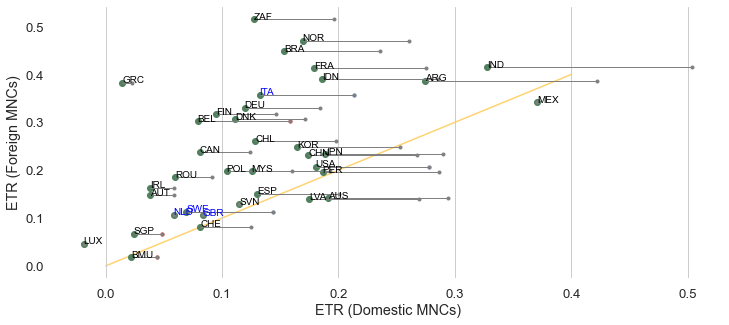

In [7]:
#Check out cleaning. USe all groups to get a most comparable picture
df_etrs = main_etrs(year=year_cbcr,file=cbcr_file,g="All Sub-Groups")
df_etrs["cit"] = df_etrs.index.map(iso3_to_cit)
df_etrs

plt.figure(figsize=(12,5))
for i,row in df_etrs.iterrows():
    if row["ETR_domestic"]>-0.2:
        if i in ["NLD","GBR","ITA","SWE"]:
            color = "blue"
        else:
            color = "black"
        plt.annotate(i,(row["ETR_domestic"],row["ETR_foreign"]),color=color)
plt.plot(df_etrs["ETR_domestic"],df_etrs["ETR_foreign"],"o")


def plot_c(cs,color="tomato"):
    c,fraction = cs
    plt.plot(df_etrs.loc[c,"ETR_domestic"]*(1+fraction/(1-fraction)),df_etrs.loc[c,"ETR_foreign"],".",color=color)
    plt.plot([df_etrs.loc[c,"ETR_domestic"]*(1+fraction/(1-fraction)),df_etrs.loc[c,"ETR_domestic"]],[df_etrs.loc[c,"ETR_foreign"],df_etrs.loc[c,"ETR_foreign"]],lw=1,color=color)

d_reduction = dict()
for c in df_etrs.dropna(subset=["ETR_domestic"]).index:
    d = dict([("SWE",0.52),("ITA",0.38),("USA",0.35)]) #2017
#     d = dict([("SWE",0.52),("ITA",0.38)]) #2016
    
    if c in ["BEL","SGP","IMN","BMU"]: 
        plot_c((c,0.5),color="red")
        frac = 0.5
    elif c in ["SVN","MEX"]: #2017
#     elif c in ["SVN","USA","CHN","MEX"]: #2016
        frac = 0
    elif c in d:
        plot_c((c,d[c]),color="cornflowerblue")
        frac = d[c]
    elif c in ("GBR","NLD"): #2017
#     elif c in []: #2016
        frac = 0 #They report their figure of adjusted profits
    elif c == "LUX": #negative profits
        frac = 0
    else:
        frac = 0.35
    d_reduction[c] = frac
    plot_c((c,frac),color="gray")
        
plt.plot([0,0.4],[0,0.4],zorder=0)
plt.grid(axis="y")
sns.despine(left=True,bottom=True)
plt.xlabel("ETR (Domestic MNCs)")
plt.ylabel("ETR (Foreign MNCs)")
# plt.plot([0,0.4],[0.05,0.45])

In [8]:
# Manually adjust countries without domestic ETRs for "sub-groups with positive profits". Use all sub-groups in this case
df = pd.read_csv(cbcr_file,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
df = df.loc[df["Year"]==year_cbcr]
missing_c = (set(df.loc[(df["COU"]==df["JUR"])&(df["Grouping"]=="All Sub-Groups"),"COU"]) -
         set(df.loc[(df["COU"]==df["JUR"])&(df["Grouping"]=="Sub-Groups with positive profits"),"COU"]))
df = df.loc[df["Grouping"]=="All Sub-Groups"]
df = pd.pivot_table(df,index=["Year","COU","JUR","Partner Jurisdiction"],values="Value",columns="Variable").reset_index()
#Calculate etr
display(main_etrs(year_cbcr,df.loc[(df["JUR"].isin(missing_c))]))

#Manually adjust
d_reduction["AUT"] = 0.35 #2017 only, much lower etr domestic
d_reduction["LVA"] = 0 #2017 only, higher for etr domestic
d_reduction["POL"] = 0.35 #2016 and 2017much lower etr domestic

,ETR_foreign,ETR_domestic,ETR_total
JUR,,,
AUT,0.148571,0.038030,0.076510
LVA,0.139238,0.175093,0.165850
POL,0.198529,0.103975,0.154036


In [9]:

#Clean data CBCR
df = pd.read_csv(cbcr_file,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
df = df.loc[df["Variable"].isin(fin_needed)]
# df = df.loc[df["Grouping"]=="Sub-Groups with positive profits"]
df = df.loc[df["Year"]==year_cbcr]
df = pd.pivot_table(df,index=["Grouping","COU","JUR","Partner Jurisdiction"],values="Value",columns="Variable").reset_index()
df = df.dropna(subset=["Income Tax Paid (on Cash Basis)"])


#Countries with analysis
if "Adjusted Profit (Loss) before Income Tax" in list(df.columns):
    print("Cleaning countries with corrected data: NLD and GBR")
    display(df.loc[~np.isnan(df["Adjusted Profit (Loss) before Income Tax"])])
    df.loc[~np.isnan(df["Adjusted Profit (Loss) before Income Tax"]),"Profit (Loss) before Income Tax"] = df.loc[~np.isnan(df["Adjusted Profit (Loss) before Income Tax"]),"Adjusted Profit (Loss) before Income Tax"]

print("Cleaning countries with analysis: ITA, SWE, BEL, USA")
df["Reduction"] = df["COU"].map(d_reduction).fillna(0)

filter_ = (df["COU"]==df["JUR"])&(df["Profit (Loss) before Income Tax"]>0)

d1 = df.loc[filter_].groupby(["COU","Grouping"])["Profit (Loss) before Income Tax"].sum()/1E9
df.loc[filter_,"Profit (Loss) before Income Tax"] = df.loc[filter_,"Profit (Loss) before Income Tax"]*(1-df.loc[filter_,"Reduction"])
d2 = df.loc[filter_].groupby(["COU","Grouping"])["Profit (Loss) before Income Tax"].sum()/1E9
d = pd.concat([d1,d2],axis=1).reset_index()
display(d.loc[d["Grouping"]=="All Sub-Groups"])

print("Cleaning foreign activities in tax havens")
filter_ = (df["COU"]!=df["JUR"]) & (df["JUR"].isin(ofcs))&(df["Profit (Loss) before Income Tax"]>0)
print(df.loc[filter_,"Profit (Loss) before Income Tax"].sum()/1E9)
df.loc[filter_,"Profit (Loss) before Income Tax"] = df.loc[filter_,"Profit (Loss) before Income Tax"]*(1-0.1)
print(df.loc[filter_,"Profit (Loss) before Income Tax"].sum()/1E9)

print("Cleaning foreign activities in groups")
filter_ = (df["COU"]!=df["JUR"]) & (df["JUR"].isin(groups | {"FJT"}))&(df["Profit (Loss) before Income Tax"]>0)
print(df.loc[filter_,"Profit (Loss) before Income Tax"].sum()/1E9)
df.loc[filter_,"Profit (Loss) before Income Tax"] = df.loc[filter_,"Profit (Loss) before Income Tax"]*(1-0.05)
print(df.loc[filter_,"Profit (Loss) before Income Tax"].sum()/1E9)


df.to_excel(cbcr_output)

Cleaning countries with corrected data: NLD and GBR


Variable,Grouping,COU,JUR,Partner Jurisdiction,Adjusted Profit (Loss) before Income Tax,Income Tax Accrued - Current Year,Income Tax Paid (on Cash Basis),Number of CbCR Sub Groups,Number of CbCRs,Number of Employees,Number of Entities,Profit (Loss) before Income Tax,Tangible Assets other than Cash and Cash Equivalents,Unrelated Party Revenues
1038,All Sub-Groups,GBR,GBR,United Kingdom,7.816987e+10,1.436948e+10,1.277019e+10,394.0,394.0,3196208.0,22765.0,1.529189e+11,8.732293e+11,1.100918e+12
1814,All Sub-Groups,NLD,NLD,Netherlands,3.034746e+10,4.700153e+09,2.149026e+09,157.0,157.0,554101.0,6467.0,3.684670e+10,1.114152e+11,2.669964e+11
3564,Sub-Groups with negative profits,NLD,NLD,Netherlands,-4.666045e+09,3.518318e+08,2.831780e+08,48.0,48.0,47383.0,759.0,-4.659002e+09,1.938881e+10,1.624414e+10
4667,Sub-Groups with positive profits,GBR,GBR,United Kingdom,1.079736e+11,1.325243e+10,1.202557e+10,301.0,301.0,2388130.0,16674.0,1.827226e+11,6.470961e+11,8.586549e+11
5297,Sub-Groups with positive profits,NLD,NLD,Netherlands,3.501350e+10,4.348321e+09,1.865848e+09,109.0,109.0,506718.0,5708.0,4.150570e+10,9.202639e+10,2.507522e+11


Cleaning countries with analysis: ITA, SWE, BEL, USA


,COU,Grouping,Profit (Loss) before Income Tax,Profit (Loss) before Income Tax
0,ARG,All Sub-Groups,4.433285,2.881636
2,AUS,All Sub-Groups,88.858573,57.758073
4,AUT,All Sub-Groups,23.192344,15.075023
5,BEL,All Sub-Groups,12.577500,6.288750
7,BMU,All Sub-Groups,3.242270,1.621135
9,BRA,All Sub-Groups,88.591218,57.584292
11,CAN,All Sub-Groups,187.617297,121.951243
13,CHE,All Sub-Groups,45.508139,29.580290
15,CHL,All Sub-Groups,13.580586,8.827381
16,CHN,All Sub-Groups,726.084439,471.954886


Cleaning foreign activities in tax havens
1551.7383292922852
1396.5644963630566
Cleaning foreign activities in groups
6095.873938429548
5791.080241508071


In [10]:
# df = pd.read_csv(cbcr_file,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
df.loc[(df["COU"]=="CHN")].sort_values(by="Profit (Loss) before Income Tax").tail(10)

Variable,Grouping,COU,JUR,Partner Jurisdiction,Adjusted Profit (Loss) before Income Tax,Income Tax Accrued - Current Year,Income Tax Paid (on Cash Basis),Number of CbCR Sub Groups,Number of CbCRs,Number of Employees,Number of Entities,Profit (Loss) before Income Tax,Tangible Assets other than Cash and Cash Equivalents,Unrelated Party Revenues,Reduction
477,All Sub-Groups,CHN,JPN,Japan,NaN,1.126821e+09,1.090430e+09,91.0,91.0,14429.0,201.0,3.327114e+09,9.953122e+09,1.252196e+10,0.35
4237,Sub-Groups with positive profits,CHN,JPN,Japan,NaN,1.120063e+09,1.072648e+09,60.0,60.0,9826.0,144.0,3.424742e+09,9.656496e+09,1.193866e+10,0.35
540,All Sub-Groups,CHN,VGB,British Virgin Islands,NaN,5.504440e+07,8.990492e+06,88.0,88.0,1338.0,1519.0,6.847593e+09,1.691891e+10,5.563746e+09,0.35
4278,Sub-Groups with positive profits,CHN,VGB,British Virgin Islands,NaN,5.438494e+07,8.844931e+06,56.0,56.0,1058.0,1325.0,7.422381e+09,1.494684e+10,5.348623e+09,0.35
468,All Sub-Groups,CHN,HKG,"Hong Kong, China",NaN,2.857560e+09,2.871509e+09,196.0,196.0,85206.0,3309.0,3.527777e+10,3.350245e+11,2.522838e+11,0.35
4230,Sub-Groups with positive profits,CHN,HKG,"Hong Kong, China",NaN,2.648196e+09,2.663501e+09,128.0,128.0,78392.0,2845.0,3.807668e+10,2.907680e+11,2.203190e+11,0.35
459,All Sub-Groups,CHN,FJT,Foreign Jurisdictions Total,NaN,1.188004e+10,1.172715e+10,3499.0,264.0,1726016.0,12815.0,6.664682e+10,7.610752e+11,8.153082e+11,0.35
4224,Sub-Groups with positive profits,CHN,FJT,Foreign Jurisdictions Total,NaN,1.128522e+10,1.102925e+10,1960.0,231.0,1505201.0,9050.0,8.884883e+10,5.646975e+11,6.571910e+11,0.35
440,All Sub-Groups,CHN,CHN,China (People's Republic of),NaN,1.162422e+11,1.263219e+11,188.0,264.0,19073202.0,32765.0,4.719549e+11,5.692462e+12,5.054612e+12,0.35
4207,Sub-Groups with positive profits,CHN,CHN,China (People's Republic of),NaN,1.162120e+11,1.262832e+11,179.0,231.0,19011847.0,32515.0,4.725160e+11,5.672250e+12,5.048412e+12,0.35


In [11]:
df_etrs = main_etrs(year=year_cbcr,file=df.loc[df["Grouping"]=="Sub-Groups with positive profits"])
df_etrs["cit"] = df_etrs.index.map(iso3_to_cit)
df_etrs.loc[df_etrs["ETR_foreign"]>0.6,"ETR_foreign"] = df_etrs.loc[df_etrs["ETR_foreign"]>0.6,"cit"]
df_etrs.loc[df_etrs["ETR_total"]>0.6,"ETR_total"] = df_etrs.loc[df_etrs["ETR_total"]>0.6,"cit"]
df_etrs.to_excel(etr_output)
df_etrs.loc["AUT"]

ETR_foreign     0.113721
ETR_domestic         NaN
ETR_total       0.113721
cit             0.250000
Name: AUT, dtype: float64

Text(0.5, 1.0, '(B) Corrected for double counting')

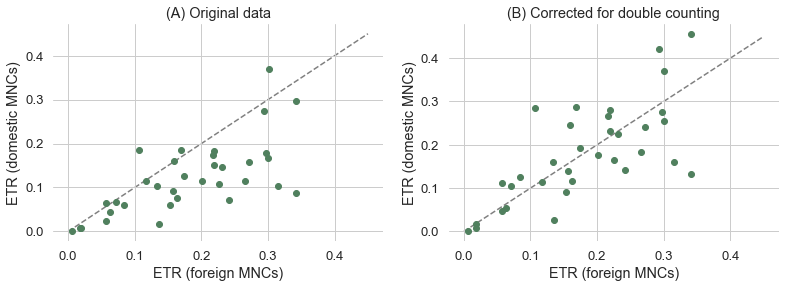

In [31]:
df_etrs2 = main_etrs(year=year_cbcr,file=cbcr_file,g="Sub-Groups with positive profits")
d = pd.concat([df_etrs, df_etrs2],axis=1)
d.columns = ["f1","d1","t1","cit","f2","d2","t2"]

def plot_etr_robustness(d,v2):
    plt.plot(d["f1"],d[v2],"o")
    plt.plot([0,0.45],[0,0.45],"--",color="gray",zorder=0)
    plt.xlabel("ETR (foreign MNCs)")
    plt.ylabel("ETR (domestic MNCs)")
    sns.despine(bottom=True,left=True)
    
plt.figure(figsize=(13,4))
plt.subplot(121)
plot_etr_robustness(d,"d2")
plt.title("(A) Original data")

plt.subplot(122)
plot_etr_robustness(d,"d1")
plt.title("(B) Corrected for double counting")

In [15]:
#Fix code for kosovo
df["COU"] = df["COU"].replace({"XKV": "XKX"})
df["JUR"] = df["JUR"].replace({"XKV": "XKX"})

In [16]:
# df_fin.loc[df_fin["iso3_o"]=="USA"].sort_values(by="pi",ascending=False)

## 2. Create other variables to train the model

## 2.1. Financial information

In [17]:
#Financial variables
df_fin = df.loc[df["Grouping"]=="All Sub-Groups",["COU","JUR","Number of Employees","Profit (Loss) before Income Tax","Income Tax Paid (on Cash Basis)","Unrelated Party Revenues","Tangible Assets other than Cash and Cash Equivalents"]]
df_fin.columns = ["iso3_o","iso3_d","emp","pi","txc","revt","t_at"]
df_fin["iso3_d"] = df_fin["iso3_d"].replace("ANT","CUW")


In [18]:
## Countries to include
countries_include = set([_ for _ in df_fin["iso3_d"].unique() if not isinstance(get_iso3(_),float)]) - {"IOT","BVT"}# - {"BVT","GUM","ASM","VIR"} #tiny ocuntry with almost no profits, not in the distance dataset

FJT not matched to any file
OAF not matched to any file
OAM not matched to any file
OAS not matched to any file
OTE not matched to any file
STA not matched to any file
AFRIC not matched to any file
AMER not matched to any file
ASIAT not matched to any file
EUROP not matched to any file
GRPS not matched to any file


## 2.2 Basic info and impute missing wages

BRN 2966.1686029849593 1651.35 0.5856779521387778
DOM 587.552837691488 295.0916666666667 0.6886801359352774
HKG 3558.4698893647055 1670.9383333333333 0.7559453012296683
IDN 309.41611151320444 145.3125 0.7558004144120035
MEX 812.9104955899793 366.63 0.7962678468440343
QAT 5692.512512643508 2780.647777777778 0.71646780289796
SDN 100.14780800792666 2864.29 3.353428605155431
SEN 114.27594217466441 0.32999999999999996 5.847278693506695
                            OLS Regression Results                            
Dep. Variable:     np.log(month_wage)   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.926
Method:                 Least Squares   F-statistic:                     795.2
Date:                Wed, 25 Aug 2021   Prob (F-statistic):           8.09e-72
Time:                        12:08:35   Log-Likelihood:                -31.922
No. Observations:                 128   AIC:                             69.84
Df Residuals

,iso3,year,IP_payments_wb,IP_receipts_wb,FDI_inflows_WDI_wb,External_debt_stocks_wb,Govt_exp_gdp_wb,Total_reserves_wb,Number_of_new_businesses_registered_wb,Imports_wb,Exports_wb,GDP_pc_wb,GDP_deflator_wb,Govt_exp_educ_gdp_wb,Physicians_per_1000_wb,Nurses_per_1000_wb,Health_exp_gdp_wb,GreenfieldFDI_outward,GreenfieldFDI_inward,resource_revenue,resource_taxes,total_taxes_revenue,cit_revenue,who_gvt_health_expenditure,month_wage,GDP_int,POP_int,FSI2020_Rank,FSI2020_Share,FSI2020_Score,CTHI21_Rank,CTHI21_Share,CTHI21_Score,region,region_tjn,EU28,OECD,G20,UKt,OECD_OCT,Physicians,Nurses,gdppc,resource_revenue_gdp,cit
0,ABW,2015.5,1.215129e+07,567378.125345,9.693186e+07,NaN,NaN,7.232144e+08,NaN,2.221448e+09,2.070436e+09,27435.662755,148.144068,1.783123e+08,NaN,NaN,NaN,50000.0,25750000.0,NaN,0.0,6.219789e+08,NaN,NaN,2203.095064,2.924859e+09,104504.3,112.0,0.002251,73.275,56.0,0.002126,70.134565,Americas,Caribbean/American isl.,0.0,0.0,0.0,0.0,1.0,NaN,NaN,27987.933810,NaN,0.267143
1,AFG,2015.5,8.262718e+06,91604.180748,7.304391e+07,2.607667e+09,8.514617e+11,6.736564e+09,3119.75,NaN,NaN,560.129995,101.993309,6.829879e+08,0.274878,0.25928,1.859401e+09,13800000.0,117475000.0,NaN,NaN,1.553641e+09,2.385878e+08,9.424014e+07,90.104194,1.930987e+10,34715394.7,NaN,NaN,NaN,NaN,NaN,NaN,Asia,Asia,0.0,0.0,0.0,0.0,0.0,9542.49055,9542.49055,556.233643,NaN,0.200000


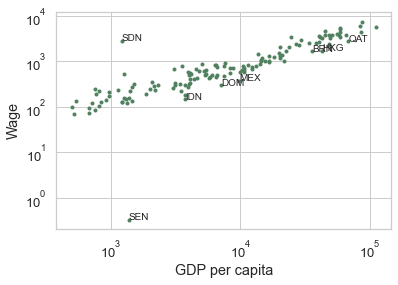

In [19]:

## Read region
region = pd.read_csv(country_level,skiprows=1,sep="\t",usecols=["iso3","region_tjn","region","UKt","OECD","OECD_OCT","EU28","G20",
                                                               "FSI2020_Rank","FSI2020_Share","FSI2020_Score","CTHI21_Rank","CTHI21_Share","CTHI21_Score"])

##Other info
usecols = ["iso3","year","GDP_int","POP_int","Physicians_per_1000_wb","Nurses_per_1000_wb","GreenfieldFDI_inward","GreenfieldFDI_outward",
           "resource_revenue","resource_taxes","total_taxes_revenue","cit_revenue","Health_exp_gdp_wb","Govt_exp_educ_gdp_wb",
          "FDI_inflows_WDI_wb","External_debt_stocks_wb",'IP_payments_wb','IP_receipts_wb','who_gvt_health_expenditure',"month_wage",
           'Total_reserves_wb','Number_of_new_businesses_registered_wb','Imports_wb','Exports_wb','GDP_pc_wb','GDP_deflator_wb','Govt_exp_gdp_wb']

ohter_info = pd.read_csv(country_year_level,skiprows=1,sep="\t",usecols=usecols)

#Fill forward to get old data (in case of missing)
for i in ["GDP_int","POP_int","Physicians_per_1000_wb","Nurses_per_1000_wb"]:
    ohter_info[i] = ohter_info.groupby(['iso3'], sort=False)[i].apply(lambda x: x.ffill(limit=3).bfill(limit=3))

#Keep mean >2010
ohter_info = ohter_info.loc[ohter_info["year"]>last_year_mean].groupby("iso3").mean().reset_index()

#Merge with region
ohter_info = pd.merge(ohter_info,region,how="outer")

#Raw numbers
ohter_info["Physicians"] = ohter_info["Physicians_per_1000_wb"]*ohter_info["POP_int"]/1000
ohter_info["Nurses"] = ohter_info["Physicians_per_1000_wb"]*ohter_info["POP_int"]/1000

#GDP per capita
ohter_info["gdppc"] = ohter_info["GDP_int"]/ohter_info["POP_int"]

#Convert to USD
for i in ['who_gvt_health_expenditure',"resource_revenue","resource_taxes","total_taxes_revenue","cit_revenue","Health_exp_gdp_wb","Govt_exp_educ_gdp_wb","Govt_exp_gdp_wb"]:
    ohter_info[i] = ohter_info[i]*ohter_info["GDP_int"]
    
ohter_info["resource_revenue_gdp"] = ohter_info["resource_revenue"]/ohter_info["GDP_int"]

ohter_info["Govt_exp_educ_gdp_wb"] /= 100
ohter_info["Health_exp_gdp_wb"] /= 100

remove = []
for i,x,y in zip(ohter_info["iso3"],ohter_info["GDP_int"]/ohter_info["POP_int"],ohter_info["month_wage"]):
    if (np.log(x/12/y)>np.log2(1.5)) or (np.log(x/12/y)<-2):
        print(i,x/12,y,np.abs(np.log(x/12/y)))
        plt.annotate(i,(x,y))
        remove.append(i)
plt.plot(ohter_info["GDP_int"]/ohter_info["POP_int"],ohter_info["month_wage"],".")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("GDP per capita")
plt.ylabel("Wage")

#Delete the problematic ones
ohter_info.loc[ohter_info["iso3"].isin(remove),"month_wage"] = np.nan


mod = smf.ols(formula='np.log(month_wage) ~ np.log(GDP_int) + np.log(POP_int)', data=ohter_info)

res = mod.fit()

print(res.summary())

ohter_info["pred_month_wage"] = np.exp(res.predict(ohter_info))
ohter_info.loc[np.isnan(ohter_info["month_wage"]),"month_wage"] = ohter_info.loc[np.isnan(ohter_info["month_wage"]),"pred_month_wage"]

del ohter_info["pred_month_wage"]
#Fix the departing ones
ohter_info.loc[ohter_info["iso3"]=="USA","month_wage"] =  4056 #https://www.bls.gov/news.release/pdf/wkyeng.pdf
ohter_info.loc[ohter_info["iso3"]=="AUS","month_wage"] =  5661 #https://www.abs.gov.au/statistics/labour/earnings-and-work-hours/average-weekly-earnings-australia/latest-release

#ADD CIT
ohter_info["cit"] = ohter_info["iso3"].map(iso3_to_cit)
ohter_info = ohter_info.drop_duplicates()

ohter_info.to_csv(info_expenditures_output, sep="\t", index=None)
 


ohter_info.head(2)

In [20]:
iso3_to_gdp = ohter_info.set_index("iso3")["GDP_int"].dropna().to_dict()
pickle.dump(iso3_to_gdp,open(iso3_to_gdp_output,"wb+"))


In [21]:
a = pd.read_csv(country_year_level,skiprows=1,sep="\t",nrows=1).columns
[_ for _ in a if "govt_ex" in _.lower()]

['Govt_exp_gdp_wb', 'Govt_exp_educ_gdp_wb', 'Govt_exp_educ_govtexp_wb']

In [22]:
#Other info
df_region = ohter_info.drop(columns=["year"])
df_region = df_region.rename(columns={"iso3":"iso3_d"})
df_region = df_region.drop_duplicates(subset=["iso3_d"]).dropna(subset=["iso3_d"])
iso3_to_region = df_region.set_index("iso3_d")["region_tjn"]

In [23]:
iso3_to_wages = ohter_info.set_index("iso3")["month_wage"].dropna().to_dict()
pickle.dump(iso3_to_wages,open(iso3_to_wages_output,"wb+"))


In [24]:
ohter_info.set_index("iso3")["month_wage"]

iso3
ABW    2203.095064
AFG      90.104194
AGO     588.850000
AIA    1767.353632
ALA    3730.441441
          ...     
UMI            NaN
PAL            NaN
ROM            NaN
TMP            NaN
ZAR            NaN
Name: month_wage, Length: 274, dtype: float64

## 2.3 Gravity dataset

In [25]:
def add_eq(df_dist,list_c,eq):
    """copies the data of another country"""
    for c in list_c:
        x = df_dist.loc[df_dist["iso3_o"]==eq]
        x["iso3_o"] = c
        df_dist = pd.concat([df_dist,x])
        x = df_dist.loc[df_dist["iso3_d"]==eq]
        x["iso3_d"] = c
        df_dist = pd.concat([df_dist,x])
    return df_dist



In [26]:
# Read gravity variables
df_dist = pd.read_stata(grav_file)
df_dist = df_dist.loc[df_dist["year"]>last_year_mean].groupby(["iso3_o","iso3_d"]).mean().reset_index()

df_dist["iso3_o"] = df_dist["iso3_o"].str.replace("ROM","ROU")
df_dist["iso3_d"] = df_dist["iso3_d"].str.replace("ROM","ROU")
df_dist["iso3_o"] = df_dist["iso3_o"].str.replace("TLS","TMP")
df_dist["iso3_d"] = df_dist["iso3_d"].str.replace("TLS","TMP")
# df_dist["iso3_o"] = df_dist["iso3_o"].str.replace("ANT","CUW")
# df_dist["iso3_d"] = df_dist["iso3_d"].str.replace("ANT","CUW")
df_dist = df_dist.loc[(df_dist["iso3_o"]!="ANT")&(df_dist["iso3_d"]!="ANT")]

df_dist = add_eq(df_dist,["JEY","IMN","GGY"],"GBR")
# df_dist = add_eq(df_dist,["SRB","MNE"],"ALB")
# df_dist = add_eq(df_dist,["MCO"],"AND")
# df_dist = add_eq(df_dist,["SSD"],"SDN")
# df_dist = add_eq(df_dist,["COD"],"COG")
df_dist = add_eq(df_dist,["TLS"],"COG")


In [27]:
df_dist["iso3_d"].value_counts().head(5) #make sure there are no duplicates

FIN    251
MKD    251
GTM    251
TCD    251
KAZ    251
Name: iso3_d, dtype: int64

In [28]:
for i in set(df_fin["iso3_d"]) - set(df_dist["iso3_o"]):
    iso3_to_name(i)

AFRIC not matched to any file
AMER not matched to any file
FJT not matched to any file
ASIAT not matched to any file
OAS not matched to any file
GRPS not matched to any file
OAF not matched to any file
OAM not matched to any file
STA not matched to any file
OTE not matched to any file
EUROP not matched to any file


## 2.4 Variables from Linkedin

In [29]:
# Linkedin variables
df_link = pd.read_csv(link_file,sep="\t",index_col=0,na_values=[""],keep_default_na=False)
df_link["iso3_d"] = df_link["index"].map(get_iso3)
df_link = df_link.drop(columns=["index","country","ln_pi"])
df_link = df_link.drop_duplicates(subset=["iso3_d"])

## 2.5 Bilateral info

In [30]:
df_bil = pd.read_csv(bilateral_level,skiprows=1,sep="\t")
df_bil = df_bil.groupby(["r_iso3","p_iso3"]).mean().reset_index()
df_bil = df_bil.loc[:,["r_iso3","p_iso3", 'Export', 'Import','dClaims','dLiabilities','PortI_inward','PortI_outward', 'FDI_inward', 'FDI_outward']]
for v in ['Export', 'Import','dClaims','dLiabilities','PortI_inward','PortI_outward', 'FDI_inward', 'FDI_outward']:
    df_bil["ln_"+v] = np.log(df_bil[v]+1)
    del df_bil[v]
    
df_bil = df_bil.rename(columns={"r_iso3":"iso3_o", "p_iso3": "iso3_d"})

df_bil

,iso3_o,iso3_d,ln_Export,ln_Import,ln_dClaims,ln_dLiabilities,ln_PortI_inward,ln_PortI_outward,ln_FDI_inward,ln_FDI_outward
0,ABW,AFG,13.558630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,AGO,16.031576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,AIA,NaN,NaN,NaN,NaN,NaN,NaN,16.234725,NaN
3,ABW,ALB,5.680173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,AND,NaN,8.065894,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
50596,ZWE,WSM,9.679281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50597,ZWE,XKX,8.497195,4.615121,NaN,NaN,NaN,NaN,NaN,NaN
50598,ZWE,YEM,12.695013,8.216298,NaN,NaN,NaN,NaN,NaN,NaN
50599,ZWE,ZAF,21.414037,21.765608,18.801398,17.95201,17.530718,NaN,20.997196,19.539148


## 2.5 Combine datasets into a bilateral dataset

In [31]:
iso3_to_etr = df_etrs["ETR_total"].to_dict()

In [32]:
## Dataset to impute (financials and weird stuff) (destination files)
#Keep the non-bilateral columns (note the drop_duplicates)
x = df_dist.loc[:,[_ for _ in df_dist.columns if  (_[-2:]=="_d") and (_ not in ["heg_d","gsp_d_d","gsp_o_d","eu_d","tradeflow_comtrade_d","tradeflow_imf_d"])]].drop_duplicates()
print(x.shape) #should be around 257 countries

df_destination = pd.merge(x,df_region,how="outer")
df_destination = pd.merge(df_destination,df_link.drop(columns=["cit","ln_gdp"]),how="left",on=["iso3_d"],suffixes=["","_d"])
df_destination["n_companies_orb"] = df_destination["iso3_d"].map(expected_companies).fillna(0)

#Add efective tax rate
df_destination["etr_real_d"] = df_destination["iso3_d"].map(iso3_to_etr)
df_destination["ln_etr_real_d"] = np.log(0.001+df_destination["etr_real_d"])
df_destination = df_destination.dropna(subset=["GDP_int"])

remove_cols_dest = df_destination.columns

#Take the logarithm for many variiables
columns = np.array(df_destination.columns)[df_destination.dtypes!=object]
for var in columns:
    if (var == "english") or (var == "etr") or ("ln" in var) or ("comrelig" in var) or ("comleg" in var):
        continue
    if len(df_destination.loc[:,var].unique()) < 5:
        continue
    m = np.min(df_destination.loc[:,var].dropna())
    if m>0:
        m = 0
#     print(var,m,np.mean(df_destination.loc[:,var]-m)/(np.median(df_destination.loc[:,var].dropna()-m)))
    if ("GDP" in var) or (var == "distw") or ((np.mean(df_destination.loc[:,var]-m) > 2.*np.median(df_destination.loc[:,var].dropna()-m))):# or (var in ["Total FSI","cthi"]):
        print(var,m,np.mean(df_destination.loc[:,var]-m)/(np.median(df_destination.loc[:,var].dropna()-m)))
        df_destination["ln_"+var] = np.log(1+df_destination.loc[:,var]-m)
        del df_destination[var]
        
        
        

(251, 17)
pop_d 0 5.071488519028965
gdp_d 0 14.544437746813971
gdpcap_d 0 2.5596123
gdp_ppp_d 0 8.619312394599774
pop_pwt_d 0 4.570007
gdp_ppp_pwt_d 0 8.659602
entry_cost_d 0.0 2.3727594836165977
IP_payments_wb 0.0 120.38330970972694
IP_receipts_wb -1450000.0 647.8683255998084
FDI_inflows_WDI_wb -3761433333.3333335 5.182915392775873
External_debt_stocks_wb 0 6.907675307749497
Govt_exp_gdp_wb 0 28.822117601937318
Total_reserves_wb 0 13.170983650721626
Number_of_new_businesses_registered_wb 0 3.9664807804690643
Imports_wb 0 17.130536446043426
Exports_wb 0 18.96971340811377
GDP_pc_wb 0 2.603988356088702
GDP_deflator_wb 0 1.821617901453778
Govt_exp_educ_gdp_wb 0 36.02718068332465
Health_exp_gdp_wb 0 42.96293023058605
GreenfieldFDI_outward 0.0 70.98344280028788
GreenfieldFDI_inward 0.0 9.844894419138324
resource_revenue 0.0 247.98724407406124
resource_taxes 0.0 inf
total_taxes_revenue 0 21.34250185167853
cit_revenue 0.0 15.89187896181312
who_gvt_health_expenditure 0 34.53550868457488


<ipython-input-32-c1a58f761145>:29: RuntimeWarning: divide by zero encountered in double_scalars
  print(var,m,np.mean(df_destination.loc[:,var]-m)/(np.median(df_destination.loc[:,var].dropna()-m)))


month_wage 0 2.049215310034562
GDP_int 0 36.23981586309734
POP_int 0 12.516955996088964
CTHI21_Share 0 2.1746450408824995
Physicians 0 15.4995366813464
Nurses 0 15.4995366813464
gdppc 0 2.6706561674610887
resource_revenue_gdp 0.0 8.044626590452186
n_companies_orb 0.0 inf


In [33]:
df_destination = df_destination.loc[(df_destination["iso3_d"]!="WLD")]

columns = np.array(df_destination.columns)[df_destination.dtypes!=object]
# df_destination = impute(df_destination,columns)


df_destination.columns = [_+"_d" if _[-2:]!="_d" else _ for _ in df_destination.columns]

for var in ["ln_resource_revenue_d", "ln_resource_revenue_gdp_d","ln_total_taxes_revenue_d","ln_cit_revenue_d"]:
    df_destination.loc[df_destination[var]<0,var] = 0


df_destination2 = df_destination.copy()
df_destination2.columns = [_[:-1]+"o" if _[-2:]=="_d" else _ for _ in df_destination.columns]

# #Add dummies
# df_destination = pd.concat([df_destination,pd.get_dummies(df_destination["iso3_d"])],axis=1)

print(df_destination.shape)

countries_include - set(df_destination["iso3_d"])

(239, 89)


set()

In [34]:
#Create a full dataset
pairs = list(product(countries_include,repeat=2))
pairs = pd.DataFrame(pairs,columns=["iso3_o","iso3_d"])

pairs = pd.merge(pairs, df_fin,how="left",validate="1:1")
pairs = pd.merge(pairs,df_destination,how="left",on=["iso3_d"],validate="m:1")
pairs = pd.merge(pairs,df_destination2,how="left",suffixes=["_d","_o"],on=["iso3_o"],validate="m:1")

df_dist2 = df_dist.loc[:,["iso3_o","iso3_d"]+[_ for _ in df_dist if (_ not in df_destination.columns) and (_ not in df_destination2.columns) and ("ln"+_ not in df_destination.columns) and ("ln"+_ not in df_destination2.columns) and (_ not in remove_cols_dest)]]
pairs = pd.merge(pairs,df_dist2,how="left",on=["iso3_o","iso3_d"],validate="1:1")
pairs = pd.merge(pairs,df_bil,how="left",on=["iso3_o","iso3_d"],validate="1:1")

# pairs = pairs.drop(columns=["conflict","indepdate","sever","sib_conflict","pta_bb","fta_bb","fta_hmr"])
pairs = pairs.drop(columns=["sib_conflict"])


print(pairs.dropna(subset=["pi"]).shape)

(1138, 231)


In [35]:
pairs["ln_etr_real_o"] = np.log(0.01+pairs["etr_real_o"])
pairs["ln_etr_real_d"] = np.log(0.01+pairs["etr_real_d"])

In [36]:
pairs["ln_cit_o"] = np.log(0.01+pairs["cit_o"])
pairs["ln_cit_d"] = np.log(0.01+pairs["cit_d"])

In [37]:
set(["gdp_o","pop_o","gdpcap_o","entry_cost_o","area_o","eu_o","eu_d","year","region_d","region_o"])-set(pairs.columns)

{'area_o'}

In [38]:
pairs = pairs.drop(columns=["gdp_o","pop_o","gdpcap_o","entry_cost_o","eu_o","eu_d","year","region_d","region_o"])

In [39]:
for i in pairs.columns:
    if len(pairs)-pairs[i].count() > 0 :
        print(i,len(pairs)-pairs[i].count())

emp 32350
pi 32351
txc 32350
revt 32351
t_at 32350
iso3num_d 183
country_exists_d 183
gmt_offset_2020_d 183
gdpcap_ppp_d 2562
gatt_d 183
wto_d 183
entry_proc_d 3294
entry_time_d 3294
entry_tp_d 3294
Physicians_per_1000_wb_d 4026
Nurses_per_1000_wb_d 3843
FSI2020_Rank_d 12078
FSI2020_Share_d 12078
FSI2020_Score_d 12078
CTHI21_Rank_d 21777
CTHI21_Score_d 21777
cit_d 1830
ratings_d 549
english_d 549
Total FSI_d 549
ln_accountant_d 549
ln_all_tax_d 549
ln_banker_d 549
ln_ceo_d 549
ln_cfo_d 549
ln_coo_d 549
ln_cxo_d 549
ln_engineer_d 549
ln_other_corporate_d 549
ln_physician_d 549
ln_tax_compliance_audit_d 549
ln_transfer_pricing_d 549
ln_wealth_d 549
ln_audience_d 549
ln_consumption_d 549
ln_gfcf_d 549
ln_population_d 549
ln_uhnwi_d 549
ln_BIS_d 549
ln_finance_d 549
governance_d 549
tax_complex_d 549
cthi_d 549
etr_real_d 6588
ln_etr_real_d 6588
ln_pop_d 366
ln_gdp_d 1281
ln_gdpcap_d 1281
ln_gdp_ppp_d 2562
ln_pop_pwt_d 3111
ln_gdp_ppp_pwt_d 3111
ln_entry_cost_d 3294
ln_IP_payments_wb_d 530

In [40]:
# #fill missing (very few values coming from the distancefile only)
# columns = np.array(pairs.columns)[pairs.dtypes!=object]
# columns = [_ for _ in columns if _ not in df_fin.columns]

# # pairs = impute(pairs,columns)

In [41]:
for var in ["emp","revt","pi","t_at","distw"]:
    pairs["ln_"+var] = np.log(1+pairs.loc[:,var]-m)
    del pairs[var]

C:\Users\javga\Anaconda3\envs\oecd\lib\site-packages\pandas\core\series.py:679: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [42]:
pairs.to_csv(df_pairs_output,sep="\t",index=None)
df_fin.to_csv(df_fin_output,sep="\t",index=None)

In [43]:
df_fin.head()

,iso3_o,iso3_d,emp,pi,txc,revt,t_at
0,AUS,ARE,1358.0,9.555555e+06,6.617933e+05,1.139530e+08,2.263228e+07
1,AUS,ARG,1689.0,7.258364e+07,3.020808e+07,6.653347e+08,1.708993e+08
2,AUS,AUS,1019661.0,4.336175e+10,1.069878e+10,4.096232e+11,3.725858e+11
3,AUS,AUT,165.0,5.863741e+06,1.381953e+06,9.749574e+07,1.132811e+07
4,AUS,BEL,1475.0,7.033835e+07,2.081644e+07,9.155861e+08,5.098251e+08


In [44]:
pairs.head()

,iso3_o,iso3_d,txc,iso3num_d,country_exists_d,gmt_offset_2020_d,gdpcap_ppp_d,gatt_d,wto_d,entry_proc_d,entry_time_d,entry_tp_d,Physicians_per_1000_wb_d,Nurses_per_1000_wb_d,FSI2020_Rank_d,FSI2020_Share_d,FSI2020_Score_d,CTHI21_Rank_d,CTHI21_Score_d,region_tjn_d,EU28_d,OECD_d,G20_d,UKt_d,OECD_OCT_d,cit_d,ratings_d,english_d,Total FSI_d,ln_accountant_d,ln_all_tax_d,ln_banker_d,ln_ceo_d,ln_cfo_d,ln_coo_d,ln_cxo_d,ln_engineer_d,ln_other_corporate_d,ln_physician_d,ln_tax_compliance_audit_d,ln_transfer_pricing_d,ln_wealth_d,ln_audience_d,ln_consumption_d,ln_gfcf_d,ln_population_d,ln_uhnwi_d,ln_BIS_d,ln_finance_d,governance_d,...,ln_Nurses_o,ln_resource_revenue_gdp_o,ln_n_companies_orb_o,contig,dist,distcap,distwces,dist_source,comlang_off,comlang_ethno,comcol,comrelig,col45,comleg_pretrans,comleg_posttrans,transition_legalchange,heg_o,heg_d,col_dep_ever,col_dep,col_dep_end_year,col_dep_end_conflict,sibling_ever,sibling,sever_year,gdp_ppp_o,pop_pwt_o,gdp_ppp_pwt_o,rta,tradeflow_comtrade_o,tradeflow_comtrade_d,tradeflow_baci,manuf_tradeflow_baci,tradeflow_imf_o,tradeflow_imf_d,ln_Export,ln_Import,ln_dClaims,ln_dLiabilities,ln_PortI_inward,ln_PortI_outward,ln_FDI_inward,ln_FDI_outward,ln_cit_o,ln_cit_d,ln_emp,ln_revt,ln_pi,ln_t_at,ln_distw
0,AUT,AUT,8.414835e+08,40.0,1.0,1.0,50.729778,1.0,1.0,8.000000,22.555556,30.555555,5.064170,6.98817,36.0,0.009310,56.500,33.0,55.683059,Europe,1.0,1.0,0.0,0.0,0.0,0.250000,96.000000,-5.551115e-17,55.900000,8.380457,7.951911,6.888572,9.660843,7.230563,6.938284,8.026497,10.420226,5.673323,7.993282,4.110874,3.433987e+00,6.042633,14.076413,26.110349,25.313034,15.980449,5.399601,12.275841,10.066924,3.665219,...,10.689403,0.0,3.295837,0.0,108.919998,108.919998,62.765,1.0,0.0,0.0,0.0,0.792805,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,4.389553e+08,8616.379883,408122720.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.347074,-1.347074,12.673714,25.575684,23.185626,25.42681,5.038627
1,AUT,BGD,NaN,50.0,1.0,6.0,3.553889,1.0,1.0,9.000000,21.311111,30.311111,0.496370,0.29583,54.0,0.006719,72.725,NaN,NaN,Asia,0.0,0.0,0.0,0.0,0.0,0.264286,40.000000,-2.775558e-16,67.129528,8.818926,7.123673,8.590630,10.454236,7.074117,7.616284,8.357259,11.163524,5.602119,8.725994,3.713572,2.220446e-16,3.931826,14.808059,25.480262,24.643751,18.877819,0.892551,9.774745,10.506464,-1.908706,...,10.689403,0.0,3.295837,0.0,6911.951172,6911.951172,7008.433,1.0,0.0,0.0,0.0,0.007060,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,4.389553e+08,8616.379883,408122720.0,0.0,7.026885e+04,5.496005e+04,6.197929e+04,6.170941e+04,7.275665e+04,6.895092e+04,17.975321,20.047628,NaN,NaN,15.248682,14.095348,NaN,14.660904,-1.347074,-1.293585,NaN,NaN,NaN,NaN,8.855580
2,AUT,KOR,NaN,410.0,1.0,9.0,36.236889,1.0,1.0,3.111111,5.666667,8.777778,2.248240,6.24728,21.0,0.012072,61.575,NaN,NaN,Asia,0.0,1.0,1.0,0.0,0.0,0.235714,86.000000,-2.775558e-16,59.025000,8.058644,6.846943,6.196444,10.707527,7.365813,7.512618,8.333511,10.789958,4.948760,7.723562,3.433987,3.044522e+00,4.510860,14.690188,27.167117,26.706196,17.751675,6.622041,12.636064,9.585415,1.961521,...,10.689403,0.0,3.295837,0.0,8289.029297,8289.029297,8466.319,1.0,0.0,0.0,0.0,0.042562,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,4.389553e+08,8616.379883,408122720.0,1.0,1.198142e+06,1.395317e+06,1.302482e+06,1.293703e+06,1.108565e+06,1.394259e+06,20.906261,20.610190,19.272788,18.629179,18.787820,20.126979,19.788928,20.779923,-1.347074,-1.403586,NaN,NaN,NaN,NaN,9.044400
3,AUT,IRQ,NaN,368.0,1.0,3.0,13.971667,0.0,0.0,9.222222,29.055556,38.277779,0.787840,1.94446,NaN,NaN,NaN,NaN,NaN,Asia,0.0,0.0,0.0,0.0,0.0,0.150000,25.000000,0.000000e+00,65.906103,8.641356,4.394449,5.252273,7.490529,4.709530,4.615121,6.111467,10.747659,3.044522,8.641356,3.044522,0.000000e+00,3.044522,13.662477,24.502273,23.541096,17.413268,0.747422,7.899153,8.566174,-3.459958,...,10.689403,0.0,3.295837,0.0,2861.763916,2861.763916,2926.107,1.0,0.0,0.0,0.0,0.021732,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0

In [45]:
df_region_notna = df_region.dropna(subset=["iso3_d","region_tjn"])
OAF = AFRIC = set(df_region_notna.loc[df_region_notna["region_tjn"]=="Africa","iso3_d"].dropna())
OAS = ASIAT = set(df_region_notna.loc[df_region_notna["region_tjn"]=="Asia","iso3_d"].dropna())
OTE = EUROP = set(df_region_notna.loc[df_region_notna["region_tjn"]=="Europe","iso3_d"].dropna())
OAM = LAC_sca = set(df_region_notna.loc[df_region_notna["region_tjn"].str.contains("America"),"iso3_d"].dropna())
GRPS = set(df_region_notna["iso3_d"].dropna())
LAC = set(df_region_notna.loc[df_region_notna["region_tjn"]=="Latin America and the Caribbean","iso3_d"].dropna())

d_groups2countries = {"OAF": OAF,
                     "AFRIC": AFRIC,
                     "OAS": OAS,
                     "ASIAT": ASIAT,
                     "OTE": OTE,
                     "EUROP": EUROP,
                     "OAM": OAM,
                     "LAC_sca": LAC_sca,
                     "GRPS": GRPS,
                     "LAC": LAC}

pickle.dump(d_groups2countries,open(d_groups2countries_output,"wb+"))
